In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import scienceplots
from tqdm.auto import tqdm

plt.style.use(["science", "no-latex"])

import itertools
from time import perf_counter

from joblib import Parallel, delayed

import geodesiq as gq

print(f"The version of geodesiq used in this script is: {gq.__version__}")

The version of geodesiq used in this script is: 0.2.0


In [6]:
FIGURE_WIDTH = 5.9  # inches
LINEWIDTH = 2
FONTSIZE_LABEL = 10.5

Useful functions for the rest of the script

In [7]:
def fidelity_vs_time(durations, model, controls: dict | None = None):
    controls = controls or {}

    model.set_control(**controls)

    model.solve_problem()

    def _worker(duration, model):
        dynamics = gq.Dynamics(duration=duration, model=model)
        return dynamics.state_fidelity()

    fidelities = Parallel(n_jobs=-1)(
        delayed(_worker)(duration, model) for duration in tqdm(durations, desc="Computing fidelities")
    )

    return np.array(fidelities)

# State transfer intro + Landau-Zener plots

In [8]:
# ----- Define ControlModel -----
def ham(z, x):
    return np.array([[z, x], [x, -z]])


# ----- Set system and control parameters -----
alpha, beta = 2, 2
x = 1
z0, zf = -10, 10

# model_lz = gq.ControlModel(ham)
model_lz = gq.ControlModel(H_c=ham(1, 0), H_d=ham(0, x))

# model_lz.set_parameters(x=x)
model_lz.set_control(control_name="z", pulse_initial=z0, pulse_final=zf, initial_state=0, alpha=alpha, beta=beta)

In [9]:
# Run the fidelity sweep for FAQUAD and geometric pulses
durations = np.linspace(0.01, 10, 200)
fidelity_linear = fidelity_vs_time(
    durations, model_lz, controls={"alpha": 0, "beta": 0}
)  # Constant metric, ie linear pulse
fidelities_geometric = fidelity_vs_time(durations, model_lz, controls={"alpha": 2, "beta": 2})
fidelities_faquad = fidelity_vs_time(durations, model_lz, controls={"alpha": 4, "beta": 2})

Computing fidelities:   0%|          | 0/200 [00:00<?, ?it/s]

Computing fidelities:   0%|          | 0/200 [00:00<?, ?it/s]

Computing fidelities:   0%|          | 0/200 [00:00<?, ?it/s]

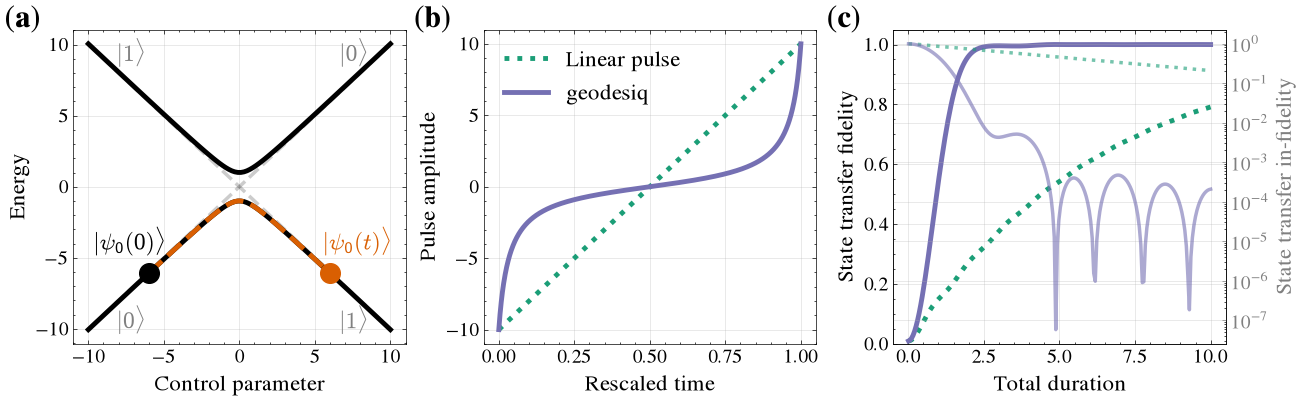

In [28]:
C_SPECTRUM = "#d95f02"  # blue
C_GEOMETRIC = "#7570b3"
C_LINEAR = "#1b9e77"
linewidth = 3.5
fontsize_label = 16


def return_pulse(model):
    return model._control_sol


# Call solve so _control_sol is populated for each model before reading the pulse
model_lz.set_control(alpha=0, beta=0)
model_lz.solve_problem(pulse_accuracy=1000)
pulse_lin = return_pulse(model_lz)
t_lin = np.linspace(0, 1, len(pulse_lin))

model_lz.set_control(alpha=2, beta=2)
model_lz.solve_problem(pulse_accuracy=1000)
pulse_geo = return_pulse(model_lz)
t_geo = np.linspace(0, 1, len(pulse_geo))

fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

# ─────────────────────────────────────────────────────────────────────────────
# (a)  Eigenenergies
# ─────────────────────────────────────────────────────────────────────────────


ax_a.set_xlabel("Control parameter", fontsize=fontsize_label)
ax_a.set_ylabel("Energy", fontsize=fontsize_label)

scatter_size = 200
x = np.linspace(-10, 10, 100)
ax_a.plot(x, np.sqrt(1 + x**2), linewidth=linewidth, color="black")
ax_a.plot(x, -np.sqrt(1 + x**2), linewidth=linewidth, color="black")
ax_a.plot(x, x, linewidth=linewidth - 1, color="black", alpha=0.2, ls="dashed")
ax_a.plot(x, -x, linewidth=linewidth - 1, color="black", alpha=0.2, ls="dashed")

ax_a.text(0.13, 0.05, r"$|0\rangle$", fontsize=17, color="gray", transform=ax_a.transAxes)
ax_a.text(0.13, 0.9, r"$|1\rangle$", fontsize=17, color="gray", transform=ax_a.transAxes)

ax_a.text(0.8, 0.05, r"$|1\rangle$", fontsize=17, color="gray", transform=ax_a.transAxes)
ax_a.text(0.8, 0.9, r"$|0\rangle$", fontsize=17, color="gray", transform=ax_a.transAxes)

x_plot = np.linspace(-6, 6, 100)
ax_a.plot(x_plot, -np.sqrt(1 + x_plot**2), linewidth=linewidth, linestyle="dashed", color=C_SPECTRUM)
ax_a.scatter(x_plot[0], -np.sqrt(1 + x_plot[0] ** 2), zorder=2, s=scatter_size, color="black")
ax_a.text(0.06, 0.3, r"$|\psi_\text{0}(0)\rangle$", fontsize=17, color="black", transform=ax_a.transAxes)
ax_a.scatter(x_plot[-1], -np.sqrt(1 + x_plot[-1] ** 2), color=C_SPECTRUM, zorder=2, s=scatter_size)
ax_a.text(0.75, 0.3, r"$|\psi_\text{0}(t)\rangle$", fontsize=17, color=C_SPECTRUM, transform=ax_a.transAxes)

# ─────────────────────────────────────────────────────────────────────────────
# (b)  Pulse
# ─────────────────────────────────────────────────────────────────────────────
ax_b.plot(t_lin, pulse_lin, color=C_LINEAR, lw=linewidth, label="Linear pulse", ls="dotted")
ax_b.plot(t_geo, pulse_geo, color=C_GEOMETRIC, lw=linewidth, label="geodesiq")

ax_b.set_xlabel("Rescaled time", fontsize=fontsize_label)
ax_b.set_ylabel("Pulse amplitude", fontsize=fontsize_label)
ax_b.legend(frameon=False, fontsize=fontsize_label)

# ─────────────────────────────────────────────────────────────────────────────
# (c)  Fidelity (left) + Infidelity log-scale (right)
# ─────────────────────────────────────────────────────────────────────────────
ax_c_r = ax_c.twinx()

# Left axis — fidelity
ax_c.plot(durations, fidelity_linear, color=C_LINEAR, lw=linewidth, ls="dotted")
ax_c.plot(durations, fidelities_geometric, color=C_GEOMETRIC, lw=linewidth)
ax_c.set_ylim(0, 1.05)
ax_c.set_xlabel("Total duration", fontsize=fontsize_label)
ax_c.set_ylabel("State transfer fidelity", fontsize=fontsize_label)

# Right axis — infidelity (log)
infidelity_linear = 1 - fidelity_linear
infidelity_geometric = 1 - fidelities_geometric

ax_c_r.semilogy(durations, infidelity_linear, color=C_LINEAR, lw=linewidth - 1, alpha=0.6, ls="dotted")
ax_c_r.semilogy(durations, infidelity_geometric, color=C_GEOMETRIC, lw=linewidth - 1, alpha=0.6)
ax_c_r.set_ylabel("State transfer in-fidelity", color="gray", fontsize=fontsize_label)
ax_c_r.tick_params(axis="y", colors="gray")
ax_c_r.yaxis.set_minor_locator(ticker.LogLocator(subs="all"))

for ax in [ax_a, ax_b, ax_c, ax_c_r]:
    ax.tick_params(labelsize=14)
    ax.grid(alpha=0.4)

for i, ax in enumerate([ax_a, ax_b, ax_c]):
    ax.text(
        -0.1, 1.08, f"({chr(97 + i)})", transform=ax.transAxes, fontsize=22, fontweight="bold", va="top", ha="right"
    )

plt.show()

fig.savefig("figures/introduction.pdf")

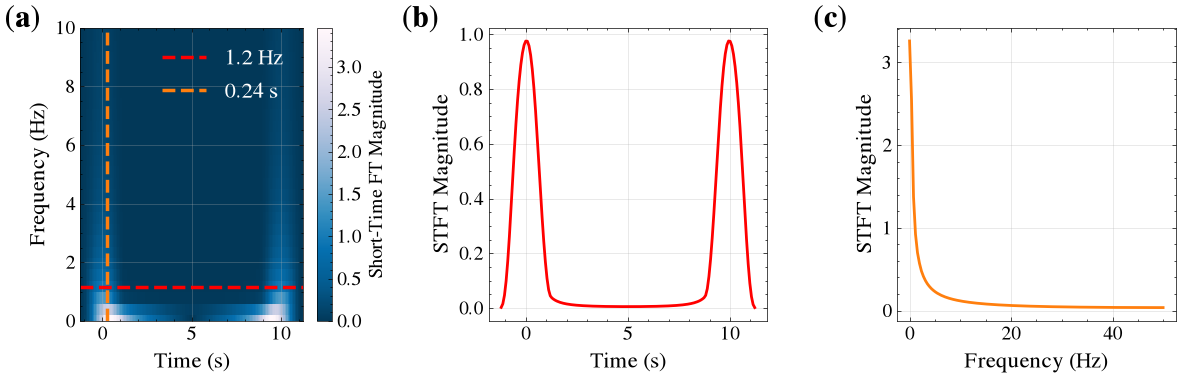

In [29]:
total_time = 10
pulse = model_lz.synthesize_pulse(duration=total_time)
freqs, times, magnitude = pulse.fourier_spectrum(window_len=256, hop=8)

target_freq = 1.0
freq_idx = np.argmin(np.abs(freqs - target_freq))

target_time = 0.25
time_idx = np.argmin(np.abs(times - target_time))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

mesh = axes[0].pcolormesh(
    times,
    freqs,
    magnitude,
    shading="auto",
    cmap="PuBu_r",
    edgecolors="none",
    linewidth=0,
    antialiased=False,
    rasterized=True,
)
cbar = fig.colorbar(mesh, ax=axes[0])
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Short-Time FT Magnitude", fontsize=14)
cbar.solids.set_edgecolor("face")

axes[0].axhline(freqs[freq_idx], color="red", lw=linewidth - 1, linestyle="--", label=f"{freqs[freq_idx]:.1f} Hz")
axes[0].axvline(times[time_idx], color="tab:orange", lw=linewidth - 1, linestyle="--", label=f"{times[time_idx]:.2f} s")
axes[0].legend(loc="upper right", fontsize=fontsize_label, labelcolor="white")
axes[0].set_xlabel("Time (s)", fontsize=fontsize_label)
axes[0].set_ylabel("Frequency (Hz)", fontsize=fontsize_label)
axes[0].set_ylim(0, 10)

axes[1].plot(times, magnitude[freq_idx, :], color="red", lw=2)
axes[1].set_xlabel("Time (s)", fontsize=fontsize_label)
axes[1].set_ylabel("STFT Magnitude", fontsize=fontsize_label)
# axes[1].set_title(f"Freq Slice @ {freqs[freq_idx]:.2f} Hz", fontsize=fontsize_label)


axes[2].plot(freqs, magnitude[:, time_idx], color="tab:orange", lw=2)
axes[2].set_xlabel("Frequency (Hz)", fontsize=fontsize_label)
axes[2].set_ylabel("STFT Magnitude", fontsize=fontsize_label)
# axes[2].set_title(f"Time Slice @ {times[time_idx]:.2f} s", fontsize=fontsize_label)


for ax in axes:
    ax.tick_params(labelsize=14)
    ax.grid(alpha=0.4)

for i, ax in enumerate(axes.flat):
    ax.text(
        -0.18, 1.08, f"({chr(97 + i)})", transform=ax.transAxes, fontsize=22, fontweight="bold", va="top", ha="right"
    )

plt.tight_layout()
plt.show()
fig.savefig("figures/LZ_freq_spectrum.pdf")

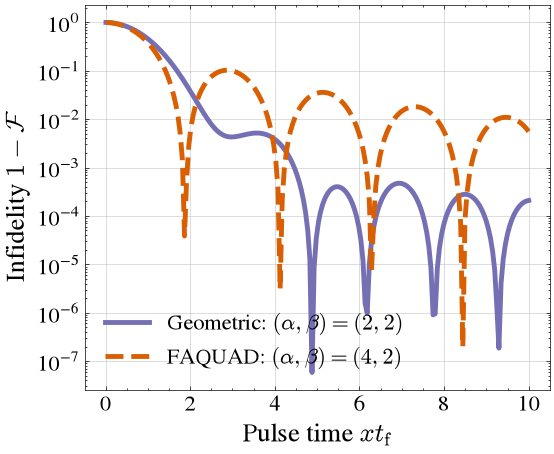

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    durations, 1 - fidelities_geometric, label=r"Geometric: $(\alpha,\beta)=(2,2)$", lw=linewidth, color=C_GEOMETRIC
)
ax.plot(
    durations,
    1 - fidelities_faquad,
    label=r"FAQUAD: $(\alpha,\beta)=(4,2)$",
    lw=linewidth,
    ls="dashed",
    color=C_SPECTRUM,
)

ax.set_yscale("log")
ax.set_ylabel(r"Infidelity $1-\mathcal{F}$", fontsize=fontsize_label + 3)
ax.set_xlabel(r"Pulse time $x t_\text{f}$", fontsize=fontsize_label + 3)
ax.legend(fontsize=fontsize_label)
ax.grid(alpha=0.6)
ax.tick_params(labelsize=16)

plt.show()
fig.savefig("figures/landau_zener.pdf")

# Pulse plot

In [29]:
# ----- Define ControlModel -----
def ham(z, x):
    return np.array([[z, x], [x, -z]])


# ----- Set system and control parameters -----
alpha, beta = 2, 2
x = 1
z0, zf = -10, 10


# model = gq.ControlModel(ham)
model = gq.ControlModel(H_c=ham(1, 0), H_d=ham(0, x))


# model.set_parameters(x=x)
model.set_control(control_name="z", pulse_initial=z0, pulse_final=zf, initial_state=0, alpha=alpha, beta=beta)

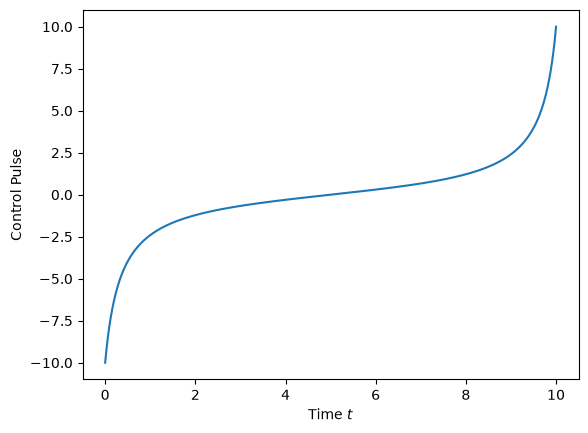

In [30]:
with plt.style.context("default"):
    pulse = model.synthesize_pulse(duration=10)
    fig, ax = pulse.plot_pulse()
fig.savefig("figures/LZ_pulse.pdf")

# DQD Model eigenenergies

In [33]:
def dqd_hamiltonian(eps, U, tc, Ez, dEz, dEx):
    ham = np.array(
        [
            [U - eps, 0, -tc, tc, 0],
            [0, Ez, dEx, -dEx, 0],
            [-tc, dEx, dEz, 0, dEx],
            [tc, -dEx, 0, -dEz, -dEx],
            [0, 0, dEx, -dEx, -Ez],
        ]
    )
    return ham


# ----- Set system and control parameters -----
alpha, beta = 2, 2

U, tc, Ez, dEz, dEx = 10, 1, 0.9, 0.1, 0.01
eps0, epsf = 15, 0

# dqd_model = gq.ControlModel(dqd_hamiltonian)
dqd_model = gq.ControlModel(H_c=dqd_hamiltonian(1, 0, 0, 0, 0, 0), H_d=dqd_hamiltonian(0, U, tc, Ez, dEz, dEx))

# dqd_model.set_parameters(U=U, tc=tc, Ez=Ez, dEz=dEz, dEx=dEx)
dqd_model.set_control(control_name="eps", pulse_initial=eps0, pulse_final=epsf, initial_state=0, alpha=alpha, beta=beta)

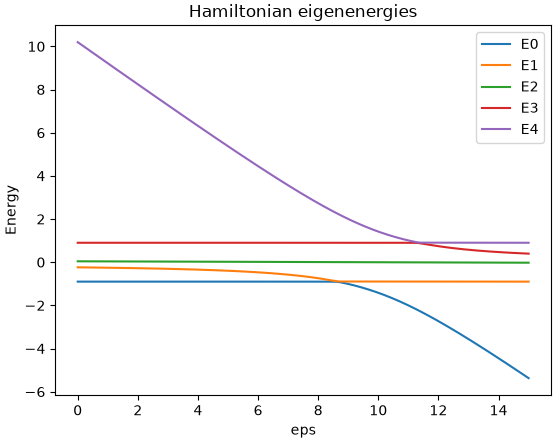

In [34]:
with plt.style.context("default"):
    fig, ax = dqd_model.plot_eigenvalues()
fig.savefig("figures/DQD_energies.pdf")

# DQD plots

In [121]:
def dqd_hamiltonian(eps, U, tc, Ez, dEz, dEx):
    ham = np.array(
        [
            [U - eps, 0, -tc, tc, 0],
            [0, Ez, dEx, -dEx, 0],
            [-tc, dEx, dEz, 0, dEx],
            [tc, -dEx, 0, -dEz, -dEx],
            [0, 0, dEx, -dEx, -Ez],
        ]
    )
    return ham


# ----- Set system and control parameters -----
alpha, beta = 2, 2

U, tc, Ez, dEz, dEx = 10, 1, 0.9, 0.1, 0.01
eps0, epsf = 15, 0

# dqd_model = gq.ControlModel(dqd_hamiltonian)
dqd_model = gq.ControlModel(H_c=dqd_hamiltonian(1, 0, 0, 0, 0, 0), H_d=dqd_hamiltonian(0, U, tc, Ez, dEz, dEx))

# dqd_model.set_parameters(U=U, tc=tc, Ez=Ez, dEz=dEz, dEx=dEx)
dqd_model.set_control(control_name="eps", pulse_initial=eps0, pulse_final=epsf, initial_state=0, alpha=alpha, beta=beta)

In [122]:
durations = np.linspace(0.01, 1000, 200)

fidelities_dqd_geometric = fidelity_vs_time(durations, dqd_model, controls={"alpha": 2, "beta": 2})
fidelities_dqd_faquad = fidelity_vs_time(durations, dqd_model, controls={"alpha": 4, "beta": 2})

Computing fidelities:   0%|          | 0/200 [00:00<?, ?it/s]

Computing fidelities:   0%|          | 0/200 [00:00<?, ?it/s]

In [114]:
def optimal_fidelity_time_map(durations, model, alphas, betas, n_jobs=-1):
    """
    Function that computes the fidelity map for a range of alpha and beta values over a range of durations.
    The function relies on the definition of fidelity_vs_time() from above.
    """

    def _worker(durations, model, alpha=2, beta=2):
        model.set_control(alpha=alpha, beta=beta)
        model.solve_problem(pulse_accuracy=int(1000))

        fidelities = []
        for duration in durations:
            dynamics = gq.Dynamics(duration=duration, model=model)
            fidelities.append(dynamics.state_fidelity())

        return np.array(fidelities)

    pairs = list(itertools.product(alphas, betas))

    results = Parallel(n_jobs=n_jobs)(
        delayed(_worker)(durations, model, alpha=alpha, beta=beta)
        for alpha, beta in tqdm(pairs, desc="Computing optimal fidelities")
    )

    fidelities = np.array(results).reshape(len(alphas), len(betas), len(durations))

    max_fidelities = np.max(fidelities, axis=2)
    best_times = durations[np.argmax(fidelities, axis=2)]

    return max_fidelities, best_times

In [82]:
durations_2d = np.linspace(0.01, 1000, 50)

alphas = np.linspace(0, 4, 75)
betas = np.linspace(0, 4, 75)

optimal_fidelities, best_times = optimal_fidelity_time_map(durations_2d, dqd_model, alphas, betas)

Computing optimal fidelities:   0%|          | 0/5625 [00:00<?, ?it/s]

In [123]:
np.savez_compressed(
    "data/dqd.npz",
    durations=durations,
    fidelities_dqd_geometric=fidelities_dqd_geometric,
    fidelities_dqd_faquad=fidelities_dqd_faquad,
    alphas=alphas,
    betas=betas,
    optimal_fidelities=optimal_fidelities,
    best_times=best_times,
)

In [124]:
data = np.load("data/dqd.npz")

durations = data["durations"]
fidelities_dqd_geometric = data["fidelities_dqd_geometric"]
fidelities_dqd_faquad = data["fidelities_dqd_faquad"]
alphas = data["alphas"]
betas = data["betas"]
optimal_fidelities = data["optimal_fidelities"]
best_times = data["best_times"]

/tmp/ipykernel_17116/873497015.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


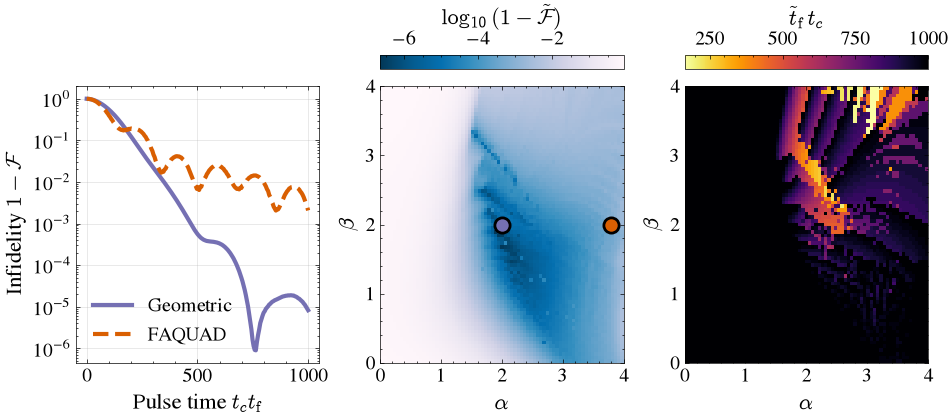

In [130]:
C_SPECTRUM = "#d95f02"
C_GEOMETRIC = "#7570b3"
C_LINEAR = "#1b9e77"
linewidth = 3.5
fontsize_label = 16

fontsizes = 14
cmap_coloring_fid = "PuBu_r"
extent = [min(alphas), max(alphas), min(betas), max(betas)]

fig = plt.figure(figsize=(11, 4))
gs = fig.add_gridspec(2, 3, height_ratios=[0.05, 1], hspace=0.12, wspace=0.25)

# Empty space above first panel, matching the colorbar row
ax_empty = fig.add_subplot(gs[0, 0])
ax_empty.axis("off")

# Colorbar axes
cax1 = fig.add_subplot(gs[0, 1])
cax2 = fig.add_subplot(gs[0, 2])

# Main axes
axs = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]

# ===== Panel (a) =====
axs[0].plot(durations, 1 - fidelities_dqd_geometric, label=r"Geometric", lw=3, color=C_GEOMETRIC)
axs[0].plot(durations, 1 - fidelities_dqd_faquad, label=r"FAQUAD", lw=3, ls="--", color=C_SPECTRUM)
axs[0].set_yscale("log")
axs[0].set_ylabel(r"Infidelity $1-\mathcal{F}$", fontsize=fontsize_label)
axs[0].set_xlabel(r"Pulse time $t_c t_\text{f}$", fontsize=fontsize_label)
axs[0].tick_params(labelsize=fontsizes)
axs[0].grid(alpha=0.4)
axs[0].legend(fontsize=14)

# ===== Panel (b) =====
infidelity_opt = np.log10(1 - optimal_fidelities.T)

im1 = axs[1].imshow(
    infidelity_opt, origin="lower", aspect="auto", interpolation="none",
    extent=extent, cmap=cmap_coloring_fid
)

axs[1].set_xlabel(r"$\alpha$", fontsize=fontsize_label)
axs[1].set_ylabel(r"$\beta$", fontsize=fontsize_label)
axs[1].tick_params(labelsize=fontsizes)

axs[1].scatter(2, 2, s=120, label="Geometric", edgecolor="black", linewidths=2, color=C_GEOMETRIC)
axs[1].scatter(3.8, 2, s=120, label="FAQUAD", edgecolor="black", linewidths=2, color=C_SPECTRUM)

cbar1 = fig.colorbar(im1, cax=cax1, orientation="horizontal")
cbar1.set_label(r"$\log_{10}(1 - \tilde{\mathcal{F}})$", size=fontsize_label)
cbar1.ax.tick_params(labelsize=fontsizes)
cbar1.ax.xaxis.set_ticks_position("top")
cbar1.ax.xaxis.set_label_position("top")

# ===== Panel (c) =====
im2 = axs[2].imshow(
    best_times.T, origin="lower", aspect="auto", interpolation="none",
    extent=extent, cmap="inferno_r"
)

axs[2].set_xlabel(r"$\alpha$", fontsize=fontsize_label)
axs[2].set_ylabel(r"$\beta$", fontsize=fontsize_label)
axs[2].tick_params(labelsize=fontsizes)

cbar2 = fig.colorbar(im2, cax=cax2, orientation="horizontal")
cbar2.set_label(r"$\tilde{t}_\text{f}\,t_c$", size=fontsize_label)
cbar2.ax.tick_params(labelsize=fontsizes)
cbar2.ax.xaxis.set_ticks_position("top")
cbar2.ax.xaxis.set_label_position("top")

plt.tight_layout()
plt.show()

fig.savefig("figures/dqd.pdf")

# Many-body spin chain

In [66]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian


def ising_model(lam, L, hx, hz):
    """
    Constructs the Ising ControlModel with transverse (hx) and longitudinal (hz) fields.
    """
    zz_list = [[lam, i, i + 1] for i in range(L - 1)]
    z_list = [[lam * hz, i] for i in range(L)]
    x_list = [[(1 - lam) * hx, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list], ["x", x_list]]

    basis = spin_basis_1d(L, pblock=1)
    H = hamiltonian(static, [], basis=basis, dtype=np.float64, check_symm=False, check_herm=False)

    return H.toarray()


def get_model(L, ising_model):
    alpha, beta = 2, 2
    initial_state = 0

    hx, hz = 1, 0.8
    lam0, lamf = 0, 1

    # model = gq.ControlModel(ising_model)

    H_d = ising_model(0, L, hx, hz)
    H_c = ising_model(1, L, hx, hz) - H_d
    model = gq.ControlModel(H_c=H_c, H_d=H_d)

    # model.set_parameters(hx=hx, hz=hz, L=L)
    model.set_control(
        control_name="lam",
        pulse_initial=lam0,
        pulse_final=lamf,
        initial_state=initial_state,
        alpha=alpha,
        beta=beta,
        num_steps=2**8 + 1,
    )

    return model

In [67]:
def fidelity_vs_time_L(durations, L, ising_model, n_jobs=-1):
    model = get_model(L, ising_model)
    model.solve_problem(pulse_accuracy=int(100))

    def _worker_compute_fidelity(duration, model):
        dynamics = gq.Dynamics(duration=duration, model=model)
        return dynamics.state_fidelity()

    # Run the loop in parallel with joblib
    fidelities = Parallel(n_jobs=n_jobs)(
        delayed(_worker_compute_fidelity)(duration, model)
        for duration in tqdm(durations, desc=f"Computing fidelities (L={L})")
    )

    return np.array(fidelities)


def pulses_and_runtime(Ls, ising_model, num_samples=100):
    runtimes = []
    control_pulses = []

    def _worker_runtime():
        start_time = perf_counter()
        model = get_model(L, ising_model)
        model.solve_problem(pulse_accuracy=int(1000))
        final_time = perf_counter() - start_time
        pulse = model._control_sol
        return final_time, pulse

    for L in Ls:        
        results = [_worker_runtime() for _ in range(num_samples)]

        # Unzip the results into two separate lists
        times, pulses = zip(*results, strict=False)
        runtimes.append(np.array(times))
        control_pulses.append(pulses[0])  # Store the first pulse as a representative

    return np.array(runtimes), np.array(control_pulses)

In [68]:
durations = np.linspace(0.1, 500, 10)
Ls = [2, 4, 6]
fids = []

for L in Ls:
    fids.append(fidelity_vs_time_L(durations=durations, L=L, ising_model=ising_model))

Computing fidelities (L=2):   0%|          | 0/10 [00:00<?, ?it/s]

Computing fidelities (L=4):   0%|          | 0/10 [00:00<?, ?it/s]

Computing fidelities (L=6):   0%|          | 0/10 [00:00<?, ?it/s]

In [69]:
Ls_runtime = [2, 4, 6]
runtimes, control_pulses = pulses_and_runtime(Ls=Ls_runtime, ising_model=ising_model)

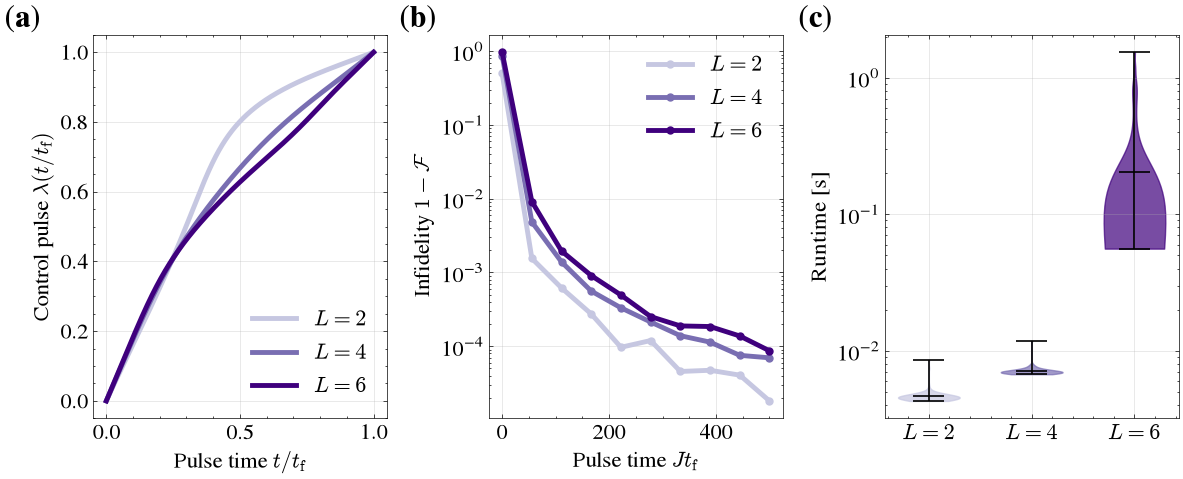

In [74]:
import matplotlib.cm as cm

linewidth = 3.5
fontsize_label = 16

L_vals = np.array(Ls)
norm = plt.Normalize(vmin=L_vals.min() - 2, vmax=L_vals.max())
colors_rgba = cm.Purples(norm(L_vals))

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# ---- a) Control pulses ----
ax = axes[0]
for i, L in enumerate(Ls):
    pulse = control_pulses[i]
    t_pulse = np.linspace(0, 1, len(pulse))
    ax.plot(t_pulse, pulse, lw=linewidth, color=colors_rgba[i], label=f"$L={L}$")
ax.set_xlabel(r"Pulse time $t/t_\text{f}$", fontsize=fontsize_label)
ax.set_ylabel(r"Control pulse $\lambda(t/t_\text{f})$", fontsize=fontsize_label)
ax.legend(fontsize=fontsize_label)

# ---- b) Infidelities ----
ax = axes[1]
for i, L in enumerate(Ls):
    ax.plot(durations, 1 - fids[i], lw=linewidth, color=colors_rgba[i], label=f"$L={L}$", marker="o", markersize=5)
ax.set_yscale("log")
ax.set_xlabel(r"Pulse time $Jt_\text{f}$", fontsize=fontsize_label)
ax.set_ylabel(r"Infidelity $1-\mathcal{F}$", fontsize=fontsize_label)
ax.legend(fontsize=fontsize_label)

# ---- c) Runtimes (violin plot) ----
L_vals_runtime = np.array(Ls_runtime)
norm = plt.Normalize(vmin=L_vals_runtime.min() - 2, vmax=L_vals_runtime.max())
colors_rgba = cm.Purples(norm(L_vals_runtime))
ax = axes[2]
x = np.arange(len(Ls_runtime))

parts = ax.violinplot(
    [runtimes[i] for i in range(len(Ls_runtime))], positions=x, widths=0.6, showmeans=True, showextrema=True
)

for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(colors_rgba[i])
    body.set_edgecolor(colors_rgba[i])
    body.set_alpha(0.7)

for key in ("cmeans", "cmins", "cmaxes", "cbars"):
    parts[key].set_color("black")
    parts[key].set_linewidth(1.2)

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([f"$L={L}$" for L in Ls_runtime])
ax.set_ylabel("Runtime [s]", fontsize=fontsize_label)

for ax in axes:
    ax.tick_params(labelsize=fontsize_label)
    ax.grid(alpha=0.4)

for i, ax in enumerate(axes.flat):
    ax.text(
        -0.18, 1.08, f"({chr(97 + i)})", transform=ax.transAxes, fontsize=22, fontweight="bold", va="top", ha="right"
    )

plt.tight_layout()
plt.show()

fig.savefig("figures/many_body.pdf")

# Appendix: Benchmarks

In [91]:
pulses = {
    "GRAPE": {"c": "C0", "ls": "-"},
    "GRAPE_random": {"c": "C1", "ls": "--"},
    "CRAB": {"c": "C2", "ls": "-."},
    "gq": {"c": "C3", "ls": ":"},
}

## LZ problem

In [109]:
data = np.load("other_qoctrl/data/LZ_results.npz")

z_vals = data["z_vals"]
energies = data["energies"]
grape_time = data["grape_time"]
grape_pulse = data["grape_pulse"]
crab_time = data["crab_time"]
crab_pulse = data["crab_pulse"]
grape_time_random = data["grape_time_random"]
grape_pulse_random = data["grape_pulse_random"]
gq_time = data["gq_time"]
gq_pulse = data["gq_pulse"]
cutoffs = data["cutoffs"]
fidelities_gq = data["fidelities_gq"]
fidelities_GRAPE = data["fidelities_GRAPE"]
fidelities_GRAPE_random = data["fidelities_GRAPE_random"]
fidelities_CRAB = data["fidelities_CRAB"]

target = 0
x_vals = z_vals
x_label = "z"

In [110]:
data = np.load("other_qoctrl/data/LZ_timing_results.npz")

n_ts_vals = data["n_ts_vals"]
times_GRAPE = data["times_GRAPE"]
times_GRAPE_random = data["times_GRAPE_random"]
times_gq = data["times_gq"]
times_CRAB = data["times_CRAB"]

/tmp/ipykernel_17116/276241877.py:88: RuntimeWarning: Mean of empty slice
  n_ts_vals, np.nanmean(times_GRAPE, axis=1), label="GRAPE (linear)", marker="o", **pulses["GRAPE"], linewidth=lw


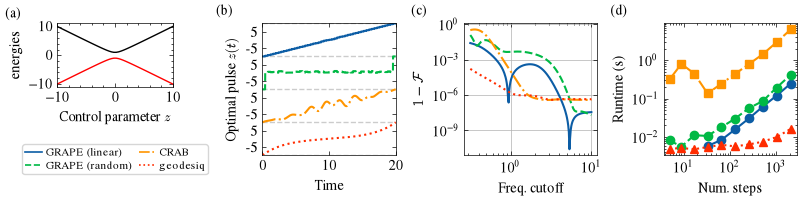

In [111]:
fig = plt.figure(figsize=(8, 2), constrained_layout=True)
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1.15, 1.15, 1.15], height_ratios=[3, 1], wspace=0.01, hspace=0.0)

lw = 1.5

# Layout:
#
# +---------+---------------+---------------+---------------+
# |    A    |               |               |               |
# | energies|       B       |       C       |       D       |
# +---------+    pulses     |   fidelity    |    runtime    |
# | legend  |               |               |               |
# +---------+---------------+---------------+---------------+

ax_energy = fig.add_subplot(gs[0, 0])
ax_legend = fig.add_subplot(gs[1, 0])

ax_pulses = fig.add_subplot(gs[:, 1])
ax_fidelity = fig.add_subplot(gs[:, 2])
ax_runtime = fig.add_subplot(gs[:, 3])


# ======= A: Eigenenergies =======

for i in range(energies.shape[1]):
    color = "r" if i == target else "k"
    ax_energy.plot(x_vals, energies[:, i], c=color)

ax_energy.set_xlabel(rf"Control parameter ${x_label}$")
ax_energy.set_ylabel("energies")
ax_energy.set_xlim(min(x_vals), max(x_vals))


# ======= B: Pulses =======

amp_ubound = np.max(gq_pulse)
amp_lbound = np.min(gq_pulse)
shift = amp_ubound - amp_lbound

ax_pulses.plot(grape_time, grape_pulse + 3 * shift, label="GRAPE (linear)", **pulses["GRAPE"], linewidth=lw)
ax_pulses.plot(
    grape_time_random, grape_pulse_random + 2 * shift, label="GRAPE (random)", **pulses["GRAPE_random"], linewidth=lw
)
ax_pulses.plot(crab_time, crab_pulse + shift, label="CRAB", **pulses["CRAB"], linewidth=lw)
ax_pulses.plot(gq_time, gq_pulse, label="geodesiq", **pulses["gq"], linewidth=lw)

for i in range(5):
    ax_pulses.axhline(amp_lbound + i * shift, ls="--", color="k", alpha=0.2, zorder=-1)

# local_ticks = ticker.MaxNLocator(nbins=3).tick_values(amp_lbound, amp_ubound)
local_ticks = np.array([-5, 5])
local_ticks = local_ticks[(local_ticks >= amp_lbound) & (local_ticks < amp_ubound)]

offsets = np.arange(4) * shift

yticks = np.concatenate([local_ticks + offset for offset in offsets])
yticklabels = np.tile([f"{tick:g}" for tick in local_ticks], len(offsets))

ax_pulses.set_yticks(yticks)
ax_pulses.set_yticklabels(yticklabels)
ax_pulses.minorticks_off()

ax_pulses.set_ylim(amp_lbound, amp_lbound + 4 * shift)
ax_pulses.set_xlim(0, max(grape_time_random))

ax_pulses.set_xlabel("Time")
ax_pulses.set_ylabel("Optimal pulse $z(t)$")


# ======= C: Fidelities =======

ax_fidelity.plot(cutoffs, 1 - fidelities_GRAPE, label="GRAPE (linear)", **pulses["GRAPE"], linewidth=lw)
ax_fidelity.plot(cutoffs, 1 - fidelities_GRAPE_random, label="GRAPE (random)", **pulses["GRAPE_random"], linewidth=lw)
ax_fidelity.plot(cutoffs, 1 - fidelities_CRAB, label="CRAB", **pulses["CRAB"], linewidth=lw)
ax_fidelity.plot(cutoffs, 1 - fidelities_gq, label="geodesiq", **pulses["gq"], linewidth=lw)

ax_fidelity.set_xscale("log")
ax_fidelity.set_yscale("log")

ax_fidelity.set_xlabel("Freq. cutoff")
ax_fidelity.set_ylabel(r"$1 - \mathcal{F}$")
ax_fidelity.grid()


# ======= D: Runtime =======

ax_runtime.loglog(
    n_ts_vals, np.nanmean(times_GRAPE, axis=1), label="GRAPE (linear)", marker="o", **pulses["GRAPE"], linewidth=lw
)
ax_runtime.loglog(
    n_ts_vals,
    np.nanmean(times_GRAPE_random, axis=1),
    label="GRAPE (random)",
    marker="o",
    **pulses["GRAPE_random"],
    linewidth=lw,
)
ax_runtime.loglog(n_ts_vals, np.nanmean(times_CRAB, axis=1), label="CRAB", marker="s", **pulses["CRAB"], linewidth=lw)
ax_runtime.loglog(n_ts_vals, np.nanmean(times_gq, axis=1), label="geodesiq", marker="^", **pulses["gq"], linewidth=lw)

ax_runtime.set_xlabel("Num. steps")
ax_runtime.set_ylabel("Runtime (s)")


# ======= Common legend for B-D =======

handles, labels = ax_pulses.get_legend_handles_labels()

ax_legend.axis("off")
leg = ax_legend.legend(handles, labels, frameon=True, ncols=2, fontsize=8,
                       handlelength=1.5, handletextpad=0.3, labelspacing=0.2, borderpad=0.25, columnspacing=0.6,
                       loc="center", bbox_to_anchor=(0.5, -0.2))
plt.setp(leg.legend_handles, linewidth=1.2)

for ax, label, x in zip(
    [ax_energy, ax_pulses, ax_fidelity, ax_runtime], ["(a)", "(b)", "(c)", "(d)"], [-0.45, -0.35, -0.4, -0.4]
):
    ax.text(x, 1.04, label, transform=ax.transAxes,  va="bottom", ha="left")
   
fig.savefig("figures/LZ_benchmarks.pdf")

## Many body problem

In [95]:
data = np.load("other_qoctrl/data/many_body_results.npz")

lam_vals = data["lam_vals"]
energies = data["energies"]
grape_time = data["grape_time"]
grape_pulse = data["grape_pulse"]
crab_time = data["crab_time"]
crab_pulse = data["crab_pulse"]
grape_time_random = data["grape_time_random"]
grape_pulse_random = data["grape_pulse_random"]
gq_time = data["gq_time"]
gq_pulse = data["gq_pulse"]
cutoffs = data["cutoffs"]
fidelities_gq = data["fidelities_gq"]
fidelities_GRAPE = data["fidelities_GRAPE"]
fidelities_GRAPE_random = data["fidelities_GRAPE_random"]
fidelities_CRAB = data["fidelities_CRAB"]

target = 6
x_vals = lam_vals
x_label = r"\lambda"

In [96]:
data = np.load("other_qoctrl/data/many_body_timing_results.npz")

n_ts_vals = data["n_ts_vals"]
times_GRAPE = data["times_GRAPE"]
times_GRAPE_random = data["times_GRAPE_random"]
times_gq = data["times_gq"]
times_CRAB = data["times_CRAB"]

/tmp/ipykernel_17116/675925657.py:88: RuntimeWarning: Mean of empty slice
  n_ts_vals, np.nanmean(times_GRAPE, axis=1), label="GRAPE (linear)", marker="o", **pulses["GRAPE"], linewidth=lw
/tmp/ipykernel_17116/675925657.py:92: RuntimeWarning: Mean of empty slice
  np.nanmean(times_GRAPE_random, axis=1),
/tmp/ipykernel_17116/675925657.py:98: RuntimeWarning: Mean of empty slice
  ax_runtime.loglog(n_ts_vals, np.nanmean(times_CRAB, axis=1), label="CRAB", marker="s", **pulses["CRAB"], linewidth=lw)
/tmp/ipykernel_17116/675925657.py:99: RuntimeWarning: Mean of empty slice
  ax_runtime.loglog(n_ts_vals, np.nanmean(times_gq, axis=1), label="geodesiq", marker="^", **pulses["gq"], linewidth=lw)


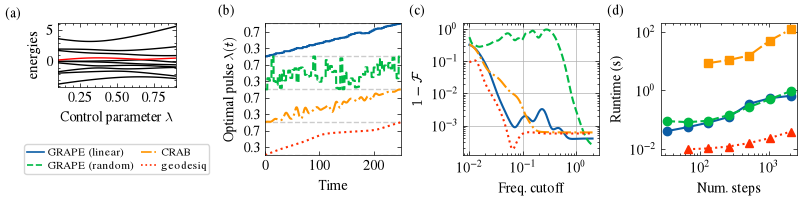

In [108]:
fig = plt.figure(figsize=(8, 2), constrained_layout=True)
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1.15, 1.15, 1.15], height_ratios=[3, 1], wspace=0.01, hspace=0.0)

lw = 1.5

# Layout:
#
# +---------+---------------+---------------+---------------+
# |    A    |               |               |               |
# | energies|       B       |       C       |       D       |
# +---------+    pulses     |   fidelity    |    runtime    |
# | legend  |               |               |               |
# +---------+---------------+---------------+---------------+

ax_energy = fig.add_subplot(gs[0, 0])
ax_legend = fig.add_subplot(gs[1, 0])

ax_pulses = fig.add_subplot(gs[:, 1])
ax_fidelity = fig.add_subplot(gs[:, 2])
ax_runtime = fig.add_subplot(gs[:, 3])


# ======= A: Eigenenergies =======

for i in range(energies.shape[1]):
    color = "r" if i == target else "k"
    ax_energy.plot(x_vals, energies[:, i], c=color)

ax_energy.set_xlabel(rf"Control parameter ${x_label}$")
ax_energy.set_ylabel("energies")
ax_energy.set_xlim(min(x_vals), max(x_vals))


# ======= B: Pulses =======

amp_ubound = np.max(gq_pulse)
amp_lbound = np.min(gq_pulse)
shift = amp_ubound - amp_lbound

ax_pulses.plot(grape_time, grape_pulse + 3 * shift, label="GRAPE (linear)", **pulses["GRAPE"], linewidth=lw)
ax_pulses.plot(
    grape_time_random, grape_pulse_random + 2 * shift, label="GRAPE (random)", **pulses["GRAPE_random"], linewidth=lw
)
ax_pulses.plot(crab_time, crab_pulse + shift, label="CRAB", **pulses["CRAB"], linewidth=lw)
ax_pulses.plot(gq_time, gq_pulse, label="geodesiq", **pulses["gq"], linewidth=lw)

for i in range(5):
    ax_pulses.axhline(amp_lbound + i * shift, ls="--", color="k", alpha=0.2, zorder=-1)

# local_ticks = ticker.MaxNLocator(nbins=3).tick_values(amp_lbound, amp_ubound)
local_ticks = np.array([0.3, 0.7])
local_ticks = local_ticks[(local_ticks >= amp_lbound) & (local_ticks < amp_ubound)]

offsets = np.arange(4) * shift

yticks = np.concatenate([local_ticks + offset for offset in offsets])
yticklabels = np.tile([f"{tick:g}" for tick in local_ticks], len(offsets))

ax_pulses.set_yticks(yticks)
ax_pulses.set_yticklabels(yticklabels)
ax_pulses.minorticks_off()

ax_pulses.set_ylim(amp_lbound, amp_lbound + 4 * shift)
ax_pulses.set_xlim(0, max(grape_time_random))

ax_pulses.set_xlabel("Time")
ax_pulses.set_ylabel(r"Optimal pulse $\lambda(t)$")


# ======= C: Fidelities =======

ax_fidelity.plot(cutoffs, 1 - fidelities_GRAPE, label="GRAPE (linear)", **pulses["GRAPE"], linewidth=lw)
ax_fidelity.plot(cutoffs, 1 - fidelities_GRAPE_random, label="GRAPE (random)", **pulses["GRAPE_random"], linewidth=lw)
ax_fidelity.plot(cutoffs, 1 - fidelities_CRAB, label="CRAB", **pulses["CRAB"], linewidth=lw)
ax_fidelity.plot(cutoffs, 1 - fidelities_gq, label="geodesiq", **pulses["gq"], linewidth=lw)

ax_fidelity.set_xscale("log")
ax_fidelity.set_yscale("log")

ax_fidelity.set_xlabel("Freq. cutoff")
ax_fidelity.set_ylabel(r"$1 - \mathcal{F}$")
ax_fidelity.grid()


# ======= D: Runtime =======

ax_runtime.loglog(
    n_ts_vals, np.nanmean(times_GRAPE, axis=1), label="GRAPE (linear)", marker="o", **pulses["GRAPE"], linewidth=lw
)
ax_runtime.loglog(
    n_ts_vals,
    np.nanmean(times_GRAPE_random, axis=1),
    label="GRAPE (random)",
    marker="o",
    **pulses["GRAPE_random"],
    linewidth=lw,
)
ax_runtime.loglog(n_ts_vals, np.nanmean(times_CRAB, axis=1), label="CRAB", marker="s", **pulses["CRAB"], linewidth=lw)
ax_runtime.loglog(n_ts_vals, np.nanmean(times_gq, axis=1), label="geodesiq", marker="^", **pulses["gq"], linewidth=lw)

ax_runtime.set_xlabel("Num. steps")
ax_runtime.set_ylabel("Runtime (s)")


# ======= Common legend for B-D =======

handles, labels = ax_pulses.get_legend_handles_labels()

ax_legend.axis("off")
leg = ax_legend.legend(handles, labels, frameon=True, ncols=2, fontsize=8,
                       handlelength=1.5, handletextpad=0.3, labelspacing=0.2, borderpad=0.25, columnspacing=0.6,
                       loc="center", bbox_to_anchor=(0.5, -0.2))
plt.setp(leg.legend_handles, linewidth=1.2)

for ax, label, x in zip(
    [ax_energy, ax_pulses, ax_fidelity, ax_runtime], ["(a)", "(b)", "(c)", "(d)"], [-0.45, -0.35, -0.4, -0.4]
):
    ax.text(x, 1.04, label, transform=ax.transAxes,  va="bottom", ha="left")
   
fig.savefig("figures/many_body_benchmarks.pdf")